## Modelling voor klachten train set
### Notebook Modelling klachten classificatie voor correcte expertise

In [2]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer, ENGLISH_STOP_WORDS
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from scipy.stats import uniform, randint
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from wordcloud import WordCloud
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer


In [3]:
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\casde\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\casde\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\casde\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [4]:
#preprocessing
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    if pd.isna(text):
        return ""
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)

train = pd.read_csv("klacht_train.csv")
test = pd.read_csv("klacht_test.csv")

train['Omschrijving_Cleaned'] = train['Omschrijving'].apply(preprocess_text)
test['Omschrijving_Cleaned'] = test['Omschrijving'].apply(preprocess_text)

y_train = train['Product']
y_test = test['Product']
x_train = train['Omschrijving_Cleaned']
x_test = test['Omschrijving_Cleaned']

In [5]:
print(len(train))
print(len(test))

9527
2382


In [6]:
#search functie
def run_search(pipeline, parameter_distributie, parameter_grid, name):
    randomized_search = RandomizedSearchCV(
        pipeline,
        param_distributions=parameter_distributie,
        n_iter=20,
        cv=5,
        scoring='precision_macro',
        n_jobs=6,
        random_state=42,
        verbose=2
    )
    randomized_search.fit(train['Omschrijving_Cleaned'], y_train)
    print(f"Randomized {name}:", randomized_search.best_params_)

    grid_search = GridSearchCV(
        pipeline,
        param_grid = parameter_grid(randomized_search.best_params_),
        cv=5,
        scoring='precision_macro',
        n_jobs=6,
        verbose=2
    )
    grid_search.fit(train['Omschrijving_Cleaned'], y_train)
    print(f"Grid {name}:", grid_search.best_params_)

    print(classification_report(
        y_test,
        grid_search.predict(test['Omschrijving_Cleaned'])
    ))
    return grid_search.best_estimator_


In [7]:
#lr
lr_pipeline = Pipeline([
    ('vect', TfidfVectorizer()),
    ('smote', SMOTE(random_state=42)),
    ('clf', LogisticRegression(max_iter=5000, solver='lbfgs')) #(clf is classifier)
])

lr_parameters = {
    'vect': [TfidfVectorizer(), CountVectorizer()],
    'vect__ngram_range': [(1,1), (1,2), (1,3)],
    'vect__max_features': randint(2000, 15000),
    'clf__C': uniform(0.1, 10),
    'clf__penalty': ['l2'],
    'clf__class_weight': [None, 'balanced']
}

def grid_lr(best):
    return {
        'vect': [best['vect']],
        'vect__ngram_range': [best['vect__ngram_range']],
        'vect__max_features': [best['vect__max_features']],
        'clf__C': [best['clf__C']*0.5, best['clf__C'], best['clf__C']*2],
        'clf__penalty': [best['clf__penalty']],
        'clf__class_weight': [best['clf__class_weight']]
    }

lr_best = run_search(lr_pipeline, lr_parameters, grid_lr, "Logistic Regression")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Randomized Logistic Regression: {'clf__C': np.float64(3.9867728968948204), 'clf__class_weight': 'balanced', 'clf__penalty': 'l2', 'vect': TfidfVectorizer(), 'vect__max_features': 11268, 'vect__ngram_range': (1, 2)}
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Grid Logistic Regression: {'clf__C': np.float64(1.9933864484474102), 'clf__class_weight': 'balanced', 'clf__penalty': 'l2', 'vect': TfidfVectorizer(), 'vect__max_features': 11268, 'vect__ngram_range': (1, 2)}
                    precision    recall  f1-score   support

      Bankrekening       0.84      0.86      0.85       240
Consumentenkrediet       0.79      0.71      0.75       156
        Creditcard       0.82      0.81      0.81       299
         Hypotheek       0.93      0.93      0.93       567
           Incasso       0.85      0.88      0.87       616
Kredietregistratie       0.86      0.84      0.85       504

          accuracy              

In [8]:
#nb
nb_pipeline = Pipeline([
    ('vect', TfidfVectorizer()),
    ('smote', SMOTE(random_state=42)),
    ('clf', MultinomialNB())
])

nb_parameters = {
    'vect': [TfidfVectorizer(), CountVectorizer()],
    'vect__ngram_range': [(1,1), (1,2)],
    'vect__max_features': randint(2000, 15000),
    'clf__alpha': uniform(0.001, 2.0)
}

def grid_nb(best):
    return {
        'vect': [best['vect']],
        'vect__ngram_range': [best['vect__ngram_range']],
        'vect__max_features': [best['vect__max_features']],
        'clf__alpha': [best['clf__alpha']*0.5, best['clf__alpha'], best['clf__alpha']*2]
    }

nb_best = run_search(nb_pipeline, nb_parameters, grid_nb, "Naive Bayes")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Randomized Naive Bayes: {'clf__alpha': np.float64(0.11382315805420051), 'vect': CountVectorizer(), 'vect__max_features': 8949, 'vect__ngram_range': (1, 2)}
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Grid Naive Bayes: {'clf__alpha': np.float64(0.22764631610840103), 'vect': CountVectorizer(), 'vect__max_features': 8949, 'vect__ngram_range': (1, 2)}
                    precision    recall  f1-score   support

      Bankrekening       0.83      0.82      0.82       240
Consumentenkrediet       0.78      0.61      0.68       156
        Creditcard       0.75      0.77      0.76       299
         Hypotheek       0.90      0.94      0.92       567
           Incasso       0.85      0.83      0.84       616
Kredietregistratie       0.82      0.84      0.83       504

          accuracy                           0.84      2382
         macro avg       0.82      0.80      0.81      2382
      weighted avg       0.83 

In [9]:
#rf
rf_pipeline = Pipeline([
    ('vect', TfidfVectorizer()),
    ('smote', SMOTE(random_state=42)),
    ('clf', RandomForestClassifier(random_state=42))
])

rf_parameters = {
    'vect': [TfidfVectorizer(), CountVectorizer()],
    'vect__ngram_range': [(1,1), (1,2)],
    'vect__max_features': randint(2000, 15000),
    'clf__n_estimators': randint(100, 300),
    'clf__max_depth': randint(10, 50),
    'clf__class_weight': [None, 'balanced']
}

def grid_rf(best):
    return {
        'vect': [best['vect']],
        'vect__ngram_range': [best['vect__ngram_range']],
        'vect__max_features': [best['vect__max_features']],
        'clf__n_estimators': [best['clf__n_estimators']-50, best['clf__n_estimators'], best['clf__n_estimators']+50],
        'clf__max_depth': [best['clf__max_depth']-5, best['clf__max_depth'], best['clf__max_depth']+5],
        'clf__class_weight': [best['clf__class_weight']]
    }

rf_best = run_search(rf_pipeline, rf_parameters, grid_rf, "Random Forest")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Randomized Random Forest: {'clf__class_weight': None, 'clf__max_depth': 48, 'clf__n_estimators': 221, 'vect': TfidfVectorizer(), 'vect__max_features': 6426, 'vect__ngram_range': (1, 1)}
Fitting 5 folds for each of 9 candidates, totalling 45 fits
Grid Random Forest: {'clf__class_weight': None, 'clf__max_depth': 43, 'clf__n_estimators': 221, 'vect': TfidfVectorizer(), 'vect__max_features': 6426, 'vect__ngram_range': (1, 1)}
                    precision    recall  f1-score   support

      Bankrekening       0.86      0.84      0.85       240
Consumentenkrediet       0.80      0.53      0.64       156
        Creditcard       0.80      0.74      0.77       299
         Hypotheek       0.90      0.93      0.92       567
           Incasso       0.80      0.84      0.82       616
Kredietregistratie       0.78      0.84      0.81       504

          accuracy                           0.83      2382
         macro avg       0.82 

In [10]:
modellen = {
    "Logistic Regression": lr_best,
    "Naïve Bayes": nb_best,
    "Random Forest": rf_best
}

In [11]:
for name, model in modellen.items():
    print(name, type(model))

Logistic Regression <class 'imblearn.pipeline.Pipeline'>
Naïve Bayes <class 'imblearn.pipeline.Pipeline'>
Random Forest <class 'imblearn.pipeline.Pipeline'>


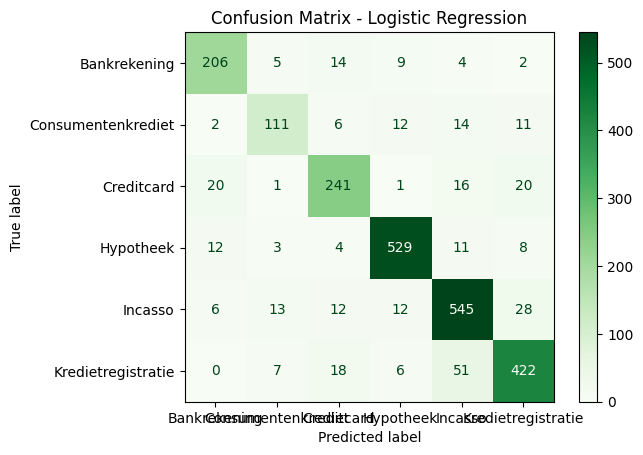

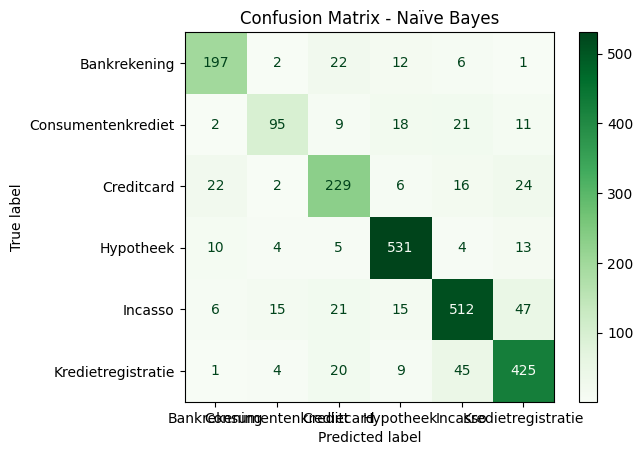

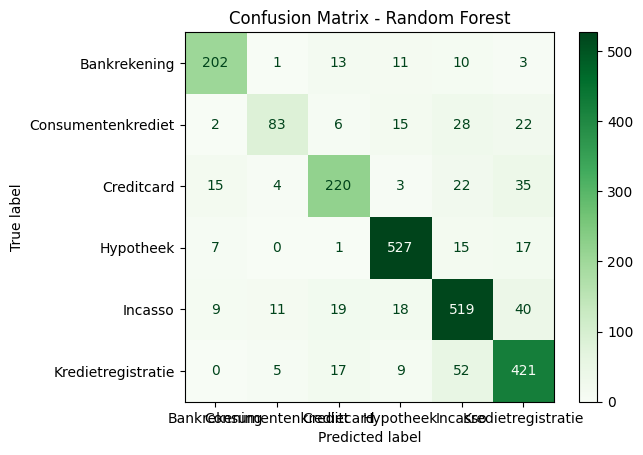

In [14]:
for name, model in modellen.items():
    y_pred = model.predict(x_test)
    confusion = confusion_matrix(y_test, y_pred)
    display = ConfusionMatrixDisplay(confusion_matrix=confusion, display_labels=model.classes_)
    display.plot(cmap="Greens")
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

In [ ]:
#